# Understanding the Effect of Different Kernels in Support Vector Machines

## Aim
The aim of this tutorial is to compare three SVM kernels: Linear, Polynomial, and RBF, and show how kernel choice affects classification performance and decision boundaries.

## Introduction
Support Vector Machines (SVMs) are supervised learning algorithms used for classification tasks. They work by finding the best boundary that separates classes. In this tutorial, we compare different kernel functions to see how they affect model performance on a non-linear dataset.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [34]:
X, y = datasets.make_moons(n_samples=300, noise=0.25, random_state=42)

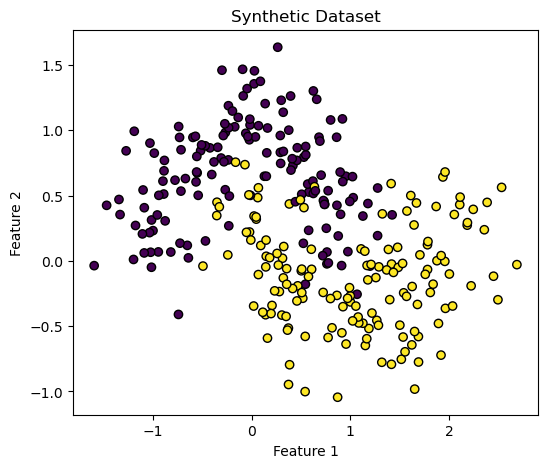

In [35]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, edgecolors="k")
plt.title("Synthetic Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.savefig("figures/dataset_visualization.png")
plt.show()

## Dataset
This tutorial uses a synthetic non-linear dataset generated with Scikit-learn using `make_moons`. It is suitable for comparing kernel functions because the classes are not perfectly separable with a straight line.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [37]:
models = {
    "Linear": SVC(kernel="linear"),
    "Polynomial": SVC(kernel="poly", degree=3),
    "RBF": SVC(kernel="rbf")
}

In [38]:
results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results[name] = {
        "model": model,
        "accuracy": acc
    }

    print(name, "Kernel Accuracy:", acc)

Linear Kernel Accuracy: 0.8888888888888888
Polynomial Kernel Accuracy: 0.8888888888888888
RBF Kernel Accuracy: 0.9


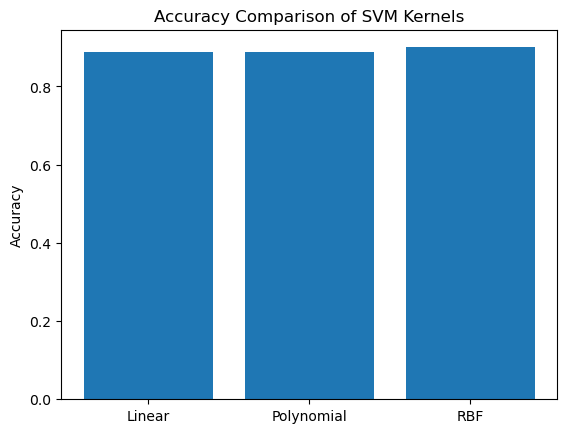

In [39]:
kernel_names = list(results.keys())
accuracies = [results[name]["accuracy"] for name in kernel_names]

plt.bar(kernel_names, accuracies)
plt.title("Accuracy Comparison of SVM Kernels")
plt.ylabel("Accuracy")
plt.savefig("figures/accuracy_comparison.png")
plt.show()

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

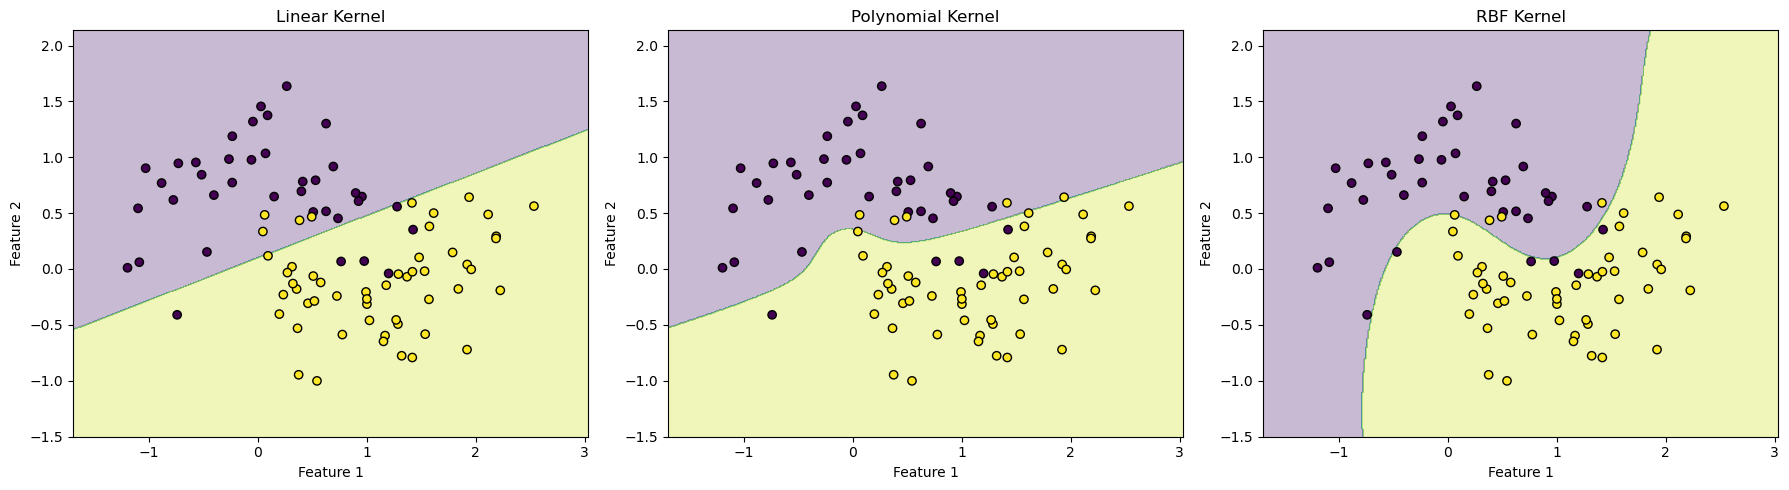

In [40]:
plt.figure(figsize=(18, 5))

for i, (name, result) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    plot_decision_boundary(result["model"], X_test, y_test, f"{name} Kernel")

plt.tight_layout()
plt.savefig("figures/kernel_boundaries.png")
plt.show()

## Decision Boundary Comparison
The figure above shows how each kernel creates a different decision boundary. The linear kernel produces a straight separation line, which is less suitable for this non-linear dataset. The polynomial kernel introduces a curved boundary, while the RBF kernel creates the most flexible boundary and is often better at handling complex class distributions.

## Conclusion

In this tutorial, we explored how different kernel functions affect the performance of Support Vector Machines (SVM). We compared three kernels: Linear, Polynomial, and RBF.

The results showed that the Linear kernel works best when the data is linearly separable. However, for more complex datasets with curved patterns, the Polynomial and RBF kernels perform better.

The RBF kernel produced the most flexible decision boundary and achieved the highest accuracy in our experiment. This demonstrates how kernel choice plays an important role in SVM classification tasks.